# LFW Identity Recognition Benchmark (with Calibration / Test splits)

Notebook này benchmark **đúng pipeline recognition hiện tại của project**:

`LFW image → SCRFD detection → ArcFace alignment 112×112 → ArcFace embedding 512-D → identity score`

Thiết kế Benchmark:
1. **Gallery split**: Chọn `NUM_ENROLLED_IDENTITIES` identity. Mỗi identity cần `MAX_GALLERY_IMAGES + CALIB_QUERY + TEST_QUERY` ảnh.
2. **Impostor split** *(tiết kiệm)*: Impostor chỉ cần `CALIB_IMPOSTOR + TEST_IMPOSTOR` ảnh — **không** reserve gallery để tối đa pool impostor.
3. **Enrolled và impostor được lấy từ hai pool eligible riêng** để thoả mãn điều kiện ảnh của từng nhóm.
4. **Calibration**: Quét threshold trên calibration splits → chọn threshold thấp nhất đạt mục tiêu FAR.
5. **Test**: Khóa threshold, đánh giá trên test splits → FAR, FRR, MIS-ID, TPIR.
6. **Gallery Size Experiment**: Lặp lại Calibration → Test cho mỗi size `1, 2, 3, 5`.


In [1]:
# =========================
# 1. BENCHMARK PARAMETERS
# =========================

from pathlib import Path
import pandas as pd
import numpy as np

NUM_ENROLLED_IDENTITIES = 100
NUM_IMPOSTOR_IDENTITIES = 300

# Bỏ size 8 vì không đủ identity có 12+ ảnh trong LFW
GALLERY_SIZES_TO_COMPARE = (1, 2, 3, 5)
MAX_GALLERY_IMAGES = max(GALLERY_SIZES_TO_COMPARE)   # = 5

CALIB_QUERY_IMAGES_PER_ID = 2
TEST_QUERY_IMAGES_PER_ID = 2

CALIB_IMPOSTOR_QUERY_IMAGES_PER_ID = 1
TEST_IMPOSTOR_QUERY_IMAGES_PER_ID = 2

# Enrolled cần: gallery + calib + test ảnh
MIN_IMAGES_ENROLLED = MAX_GALLERY_IMAGES + CALIB_QUERY_IMAGES_PER_ID + TEST_QUERY_IMAGES_PER_ID  # = 9

# Impostor KHÔNG cần reserve gallery: chỉ cần calib + test ảnh
# → pool impostor lớn hơn nhiều → FAR calibration mạnh hơn
MIN_IMAGES_IMPOSTOR = CALIB_IMPOSTOR_QUERY_IMAGES_PER_ID + TEST_IMPOSTOR_QUERY_IMAGES_PER_ID  # = 3

RANDOM_SEED = 42
OUTLIER_THRESHOLD = 0.35
THRESHOLD_START = 0.30
THRESHOLD_STOP = 0.91
THRESHOLD_STEP = 0.01

USE_CACHE = True
CACHE_DIR_NAME = "benchmark_cache"
PIPELINE_VERSION = "scrfd_arcface_v1"
WRITE_TO_VECTOR_DB = False
COMPARE_GALLERY_SIZES = True

print("Gallery sizes        :", GALLERY_SIZES_TO_COMPARE)
print("MAX_GALLERY_IMAGES   =", MAX_GALLERY_IMAGES)
print("MIN_IMAGES_ENROLLED  =", MIN_IMAGES_ENROLLED)
print("MIN_IMAGES_IMPOSTOR  =", MIN_IMAGES_IMPOSTOR)
print("Test impostor queries ~", NUM_IMPOSTOR_IDENTITIES * TEST_IMPOSTOR_QUERY_IMAGES_PER_ID)


Gallery sizes        : (1, 2, 3, 5)
MAX_GALLERY_IMAGES   = 5
MIN_IMAGES_ENROLLED  = 9
MIN_IMAGES_IMPOSTOR  = 3
Test impostor queries ~ 600


In [2]:
# =========================
# 2. PROJECT / DATASET PATH
# =========================

import sys
import os

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "config.py").exists() and (p / "data").exists():
            return p
    if (start.parent / "config.py").exists():
        return start.parent
    raise FileNotFoundError("Không tìm thấy project root.")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data"
LFW_ROOT = DATA_ROOT / "lfw"
METADATA_ROOT = DATA_ROOT / "lfw_metadata"
CACHE_ROOT = PROJECT_ROOT / "benchmark" / CACHE_DIR_NAME

print("PROJECT_ROOT :", PROJECT_ROOT)
if not LFW_ROOT.exists():
    raise FileNotFoundError(f"Không tìm thấy dataset tại {LFW_ROOT}")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)


PROJECT_ROOT : /mnt/windows/Users/62205/Documents/locngo/school/7th-semester/PBL6/SmartFace-AIoT-Based-Staff-Management-Attendance-System/face_auth


In [3]:
# =========================
# 3. METADATA + IDENTITY INVENTORY
# =========================

identity_rows = []
for identity_dir in sorted(p for p in LFW_ROOT.iterdir() if p.is_dir()):
    images = sorted([
        p for p in identity_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])
    if images:
        identity_rows.append({
            "identity": identity_dir.name,
            "image_count_fs": len(images),
            "directory": str(identity_dir),
        })

inventory = pd.DataFrame(identity_rows).sort_values(
    ["image_count_fs", "identity"], ascending=[False, True]
).reset_index(drop=True)

# Enrolled và impostor dùng ngưỡng ảnh khác nhau → pool độc lập
eligible_enrolled = inventory[inventory["image_count_fs"] >= MIN_IMAGES_ENROLLED].copy()
eligible_impostor = inventory[inventory["image_count_fs"] >= MIN_IMAGES_IMPOSTOR].copy()

print(f"Eligible ENROLLED   (>= {MIN_IMAGES_ENROLLED} images): {len(eligible_enrolled):,}")
print(f"Eligible IMPOSTOR   (>= {MIN_IMAGES_IMPOSTOR} images): {len(eligible_impostor):,}")

if len(eligible_enrolled) < NUM_ENROLLED_IDENTITIES:
    raise ValueError(f"Chỉ có {len(eligible_enrolled)} identity đủ {MIN_IMAGES_ENROLLED} ảnh cho enrolled.")


Eligible ENROLLED   (>= 9 images): 184
Eligible IMPOSTOR   (>= 3 images): 901


In [4]:
# =========================
# 4. SELECT ENROLLED + IMPOSTOR IDENTITIES
# =========================
# Enrolled và impostor được chọn từ hai pool eligible độc lập
# để impostor không cần phải có gallery ảnh (tiết kiệm constraint).

rng_enrolled  = np.random.default_rng(RANDOM_SEED)
rng_impostor  = np.random.default_rng(RANDOM_SEED + 1)

# Shuffle hai pool độc lập
enrolled_pool = eligible_enrolled["identity"].tolist()
rng_enrolled.shuffle(enrolled_pool)

impostor_pool = [
    name for name in eligible_impostor["identity"].tolist()
    if name not in set(enrolled_pool[:NUM_ENROLLED_IDENTITIES])
]
rng_impostor.shuffle(impostor_pool)

enrolled_names = sorted(enrolled_pool[:NUM_ENROLLED_IDENTITIES])
impostor_names = sorted(impostor_pool[:NUM_IMPOSTOR_IDENTITIES])

if len(impostor_names) < NUM_IMPOSTOR_IDENTITIES:
    raise ValueError(
        f"Chỉ có {len(impostor_names)} impostor identity sau khi loại enrolled. "
        f"Cần {NUM_IMPOSTOR_IDENTITIES}."
    )

print(f"Enrolled identities : {len(enrolled_names)}")
print(f"Impostor identities : {len(impostor_names)}")

def split_enrolled_images(identity_name, gallery_n, calib_n, test_n, rng):
    # Enrolled: gallery | calib | test
    images = sorted([
        p for p in (LFW_ROOT / identity_name).iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])
    idx = rng.permutation(len(images))
    g = [images[int(i)] for i in idx[:gallery_n]]
    c = [images[int(i)] for i in idx[gallery_n:gallery_n + calib_n]]
    t = [images[int(i)] for i in idx[gallery_n + calib_n:gallery_n + calib_n + test_n]]
    return g, c, t

def split_impostor_images(identity_name, calib_n, test_n, rng):
    # Impostor: KHÔNG reserve gallery → calib | test từ đầu danh sách
    images = sorted([
        p for p in (LFW_ROOT / identity_name).iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])
    idx = rng.permutation(len(images))
    c = [images[int(i)] for i in idx[:calib_n]]
    t = [images[int(i)] for i in idx[calib_n:calib_n + test_n]]
    return c, t

split_rng_e = np.random.default_rng(RANDOM_SEED + 10)
split_rng_i = np.random.default_rng(RANDOM_SEED + 20)

gallery_paths = {}
calib_query_paths = {}
test_query_paths = {}
calib_impostor_paths = {}
test_impostor_paths = {}

for name in enrolled_names:
    g, c, t = split_enrolled_images(
        name, MAX_GALLERY_IMAGES, CALIB_QUERY_IMAGES_PER_ID, TEST_QUERY_IMAGES_PER_ID, split_rng_e
    )
    gallery_paths[name]       = g
    calib_query_paths[name]   = c
    test_query_paths[name]    = t

for name in impostor_names:
    c, t = split_impostor_images(
        name, CALIB_IMPOSTOR_QUERY_IMAGES_PER_ID, TEST_IMPOSTOR_QUERY_IMAGES_PER_ID, split_rng_i
    )
    calib_impostor_paths[name] = c
    test_impostor_paths[name]  = t

print(f"Calib impostor queries : {sum(len(v) for v in calib_impostor_paths.values())}")
print(f"Test  impostor queries : {sum(len(v) for v in test_impostor_paths.values())}")

import json
split_manifest = {
    "random_seed": RANDOM_SEED,
    "max_gallery_images": MAX_GALLERY_IMAGES,
    "min_images_enrolled": MIN_IMAGES_ENROLLED,
    "min_images_impostor": MIN_IMAGES_IMPOSTOR,
    "calib_query_images_per_id": CALIB_QUERY_IMAGES_PER_ID,
    "test_query_images_per_id": TEST_QUERY_IMAGES_PER_ID,
    "enrolled": {
        name: {
            "gallery": [str(p) for p in gallery_paths[name]],
            "calib":   [str(p) for p in calib_query_paths[name]],
            "test":    [str(p) for p in test_query_paths[name]],
        }
        for name in enrolled_names
    },
    "impostor": {
        name: {
            "calib": [str(p) for p in calib_impostor_paths[name]],
            "test":  [str(p) for p in test_impostor_paths[name]],
        }
        for name in impostor_names
    },
}
split_manifest_path = NOTEBOOK_DIR / "lfw_split_manifest.json"
with open(split_manifest_path, "w", encoding="utf-8") as f:
    json.dump(split_manifest, f, indent=2, ensure_ascii=False)
print("Split manifest saved to:", split_manifest_path)


Enrolled identities : 100
Impostor identities : 300
Calib impostor queries : 300
Test  impostor queries : 600
Split manifest saved to: /mnt/windows/Users/62205/Documents/locngo/school/7th-semester/PBL6/SmartFace-AIoT-Based-Staff-Management-Attendance-System/face_auth/evaluation/lfw_split_manifest.json


In [5]:
# =========================
# 5. LOAD CURRENT PROJECT PIPELINE
# =========================

import cv2
from detection.detector import FaceDetector
from recognition.embedder import FaceEmbedder
from alignment.aligner import get_input_face
from enrollment.enroll import build_identity_embedding
import config

detector = FaceDetector(
    config.MODEL_PACK_NAME,
    ctx_id=config.MODEL_CTX_ID,
    det_size=config.DETECTOR_DET_SIZE,
    conf_thresh=config.DETECTOR_CONF_THRESH,
)

embedder = FaceEmbedder(
    config.MODEL_PACK_NAME,
    ctx_id=config.MODEL_CTX_ID,
)


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/locngodev/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/locngodev/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/locngodev/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/locngodev/.insightface/models/buffalo_s/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/locngodev/.insightface/models/buffalo_s/w600k_mbf.onnx recognition
set det-size: (640, 640)
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionPr

In [6]:
# =========================
# 6. IMAGE -> 512-D EMBEDDING
# =========================

from typing import Optional

def image_to_embedding(image_path: Path) -> Optional[np.ndarray]:
    image = cv2.imread(str(image_path))
    if image is None: return None
    detections = detector.detect(image)
    if not detections: return None
    det = max(detections, key=lambda d: d.get("score", 0.0))
    aligned = get_input_face(image, det["bbox"], det.get("landmarks"), embedder.input_size)
    if aligned is None: return None
    emb = embedder.embed_aligned(aligned)
    if emb is None: return None
    emb = np.asarray(emb, dtype=np.float32).flatten()
    norm = np.linalg.norm(emb)
    if norm == 0: return None
    return emb / norm


In [7]:
# =========================
# 7. EMBEDDING CACHE
# =========================

import hashlib
from tqdm.auto import tqdm

def cache_key(path: Path) -> str:
    stat = path.stat()
    raw = f"{path.resolve()}|{stat.st_size}|{stat.st_mtime_ns}|{config.MODEL_PACK_NAME}|{PIPELINE_VERSION}"
    return hashlib.sha1(raw.encode()).hexdigest()

def get_cached_embedding(path: Path):
    if not USE_CACHE: return image_to_embedding(path)
    cfile = CACHE_ROOT / f"{cache_key(path)}.npy"
    if cfile.exists(): return np.load(cfile).astype(np.float32)
    emb = image_to_embedding(path)
    if emb is not None: np.save(cfile, emb.astype(np.float32))
    return emb

all_paths = set()
for paths in gallery_paths.values(): all_paths.update(paths)
for paths in calib_query_paths.values(): all_paths.update(paths)
for paths in test_query_paths.values(): all_paths.update(paths)
for paths in calib_impostor_paths.values(): all_paths.update(paths)
for paths in test_impostor_paths.values(): all_paths.update(paths)
all_paths = list(all_paths)

embedding_store = {}
failures = []
for path in tqdm(all_paths, desc="Embedding"):
    emb = get_cached_embedding(path)
    embedding_store[path] = emb
    if emb is None: failures.append(path)

print(f"Failures: {len(failures)}")


Embedding:   0%|          | 0/1800 [00:00<?, ?it/s]

Failures: 4


In [8]:
# =========================
# 8. BUILD GALLERY
# =========================

def build_gallery_from_paths(gallery_paths_dict, min_valid=1):
    gallery_means, gallery_individuals = {}, {}
    for identity, paths in gallery_paths_dict.items():
        embs = [embedding_store[p] for p in paths if embedding_store[p] is not None]
        if len(embs) < min_valid: continue
        mean_emb, _, valid_embs = build_identity_embedding(embs, outlier_threshold=OUTLIER_THRESHOLD)
        gallery_means[identity] = mean_emb.astype(np.float32)
        gallery_individuals[identity] = [np.asarray(e, dtype=np.float32) for e in valid_embs]
    return gallery_means, gallery_individuals

gallery_means, gallery_individuals = build_gallery_from_paths(gallery_paths)
print("Gallery enrolled:", len(gallery_means))


Gallery enrolled: 100


In [9]:
# =========================
# 9. OPTIONAL: WRITE GALLERY TO VECTORDB
#    + EXPORT lfw_upserted_users.csv
# =========================
#
# Khi WRITE_TO_VECTOR_DB=True, notebook sẽ:
#   1. Gọi db.upsert() cho mỗi enrolled identity (prefix: benchmark_lfw_<name>)
#   2. Ghi lfw_upserted_users.csv chứa các trường:
#      user_id, name, identity, gallery_image_count, embedding_count,
#      mean_saved, individual_saved, is_new, is_ignored, upserted_at_utc

from datetime import datetime, timezone
import re

UPSERT_CSV_NAME = "lfw_upserted_users.csv"

def _safe_user_id(identity: str) -> str:
    # Prefix "benchmark_lfw_" để tránh collision với user production.
    return "benchmark_lfw_" + re.sub(r"[^a-zA-Z0-9_-]+", "_", identity)

def write_gallery_to_vectordb(
    gallery_means,
    gallery_individuals,
    enrolled_names,
    gallery_paths,
    csv_name=UPSERT_CSV_NAME,
    overwrite=True,
):
    from database.vector_db import VectorDB

    db = VectorDB(
        conninfo=config.DB_CONN_INFO,
        min_size=config.DB_POOL_MIN_SIZE,
        max_size=config.DB_POOL_MAX_SIZE,
    )

    upserted_rows = []
    try:
        for identity in enrolled_names:
            if identity not in gallery_means:
                continue
            mean_emb = gallery_means[identity]
            individuals = gallery_individuals[identity]
            user_id = _safe_user_id(identity)

            result = db.upsert(
                user_id=user_id,
                name=identity,
                individual_embeddings=individuals,
                mean_embedding=mean_emb,
                overwrite=overwrite,
                save_individuals=True,
            )
            person_id, is_new, is_ignored = result

            upserted_rows.append({
                "user_id":              person_id,
                "name":                identity,
                "identity":            identity,
                "gallery_image_count": len(gallery_paths.get(identity, [])),
                "embedding_count":     len(individuals),
                "mean_saved":          mean_emb is not None,
                "individual_saved":    len(individuals) > 0,
                "is_new":              bool(is_new),
                "is_ignored":          bool(is_ignored),
                "upserted_at_utc":     datetime.now(timezone.utc).isoformat(),
            })
    finally:
        db.close()

    manifest_df = pd.DataFrame(upserted_rows)
    output_path = NOTEBOOK_DIR / csv_name
    manifest_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Upserted: {len(manifest_df)} identities → {output_path}")
    return manifest_df, output_path


if WRITE_TO_VECTOR_DB:
    db_manifest, db_csv = write_gallery_to_vectordb(
        gallery_means=gallery_means,
        gallery_individuals=gallery_individuals,
        enrolled_names=enrolled_names,
        gallery_paths=gallery_paths,
        overwrite=True,
    )
    display(db_manifest.head(20))
else:
    db_manifest = pd.DataFrame()
    print(
        f"WRITE_TO_VECTOR_DB=False. Khi bật, CSV sẽ ghi vào:"
        f"{NOTEBOOK_DIR / UPSERT_CSV_NAME}"
    )


WRITE_TO_VECTOR_DB=False. Khi bật, CSV sẽ ghi vào:/mnt/windows/Users/62205/Documents/locngo/school/7th-semester/PBL6/SmartFace-AIoT-Based-Staff-Management-Attendance-System/face_auth/evaluation/lfw_upserted_users.csv


In [10]:
# =========================
# 10. SCORING & DATAFRAME BUILDER
# =========================

def score_queries_mean(query_embs, gallery_means):
    identities = list(gallery_means.keys())
    if not identities or not query_embs: return [None]*len(query_embs), [float("-inf")]*len(query_embs)
    matrix = np.stack([gallery_means[i] for i in identities]).astype(np.float32)
    q = np.stack(query_embs).astype(np.float32)
    sims = q @ matrix.T
    best_idx = np.argmax(sims, axis=1)
    return [identities[i] for i in best_idx], sims[np.arange(len(q)), best_idx].tolist()

def score_queries_individual(query_embs, gallery_individuals):
    labels, rows = [], []
    for identity, embs in gallery_individuals.items():
        for e in embs:
            labels.append(identity)
            rows.append(e)
    if not rows or not query_embs: return [None]*len(query_embs), [float("-inf")]*len(query_embs)
    matrix = np.stack(rows).astype(np.float32)
    q = np.stack(query_embs).astype(np.float32)
    sims = q @ matrix.T
    labels_arr = np.asarray(labels)
    unique_ids = sorted(set(labels))
    per_identity = np.stack([sims[:, labels_arr == uid].max(axis=1) for uid in unique_ids], axis=1)
    best_idx = np.argmax(per_identity, axis=1)
    return [unique_ids[i] for i in best_idx], per_identity[np.arange(len(q)), best_idx].tolist()

def build_scoring_df(paths_dict, gm, gi):
    paths_flat, true_identity = [], []
    for identity, paths in paths_dict.items():
        for path in paths:
            if embedding_store.get(path) is not None:
                paths_flat.append(path)
                true_identity.append(identity)
    if not paths_flat: return pd.DataFrame()
    embs = [embedding_store[p] for p in paths_flat]
    pred_m, score_m = score_queries_mean(embs, gm)
    pred_i, score_i = score_queries_individual(embs, gi)
    return pd.DataFrame({
        "true_identity": true_identity,
        "pred_mean": pred_m,
        "score_mean": score_m,
        "pred_individual": pred_i,
        "score_individual": score_i,
    })

# Build the 4 splits
df_calib = build_scoring_df(calib_query_paths, gallery_means, gallery_individuals)
df_test = build_scoring_df(test_query_paths, gallery_means, gallery_individuals)
df_calib_imp = build_scoring_df(calib_impostor_paths, gallery_means, gallery_individuals)
df_test_imp = build_scoring_df(test_impostor_paths, gallery_means, gallery_individuals)

print("Calib queries   :", len(df_calib))
print("Test queries    :", len(df_test))
print("Calib impostors :", len(df_calib_imp))
print("Test impostors  :", len(df_test_imp))


Calib queries   : 200
Test queries    : 200
Calib impostors : 299
Test impostors  : 599


In [11]:
# =========================
# 11. THRESHOLD EVALUATION FUNCTION
# =========================

thresholds = np.arange(THRESHOLD_START, THRESHOLD_STOP, THRESHOLD_STEP)

def evaluate_thresholds(known_df, impostor_df, score_col, pred_col, target_thresholds=None):
    rows = []
    thresh_list = target_thresholds if target_thresholds is not None else thresholds
    for threshold in thresh_list:
        accept_mask = known_df[score_col] >= threshold
        correct_accept = accept_mask & (known_df[pred_col] == known_df["true_identity"])
        wrong_accept   = accept_mask & (known_df[pred_col] != known_df["true_identity"])
        genuine_reject = ~accept_mask

        n_ca  = int(correct_accept.sum())
        n_mis = int(wrong_accept.sum())
        n_gr  = int(genuine_reject.sum())

        impostor_accept = impostor_df[score_col] >= threshold
        n_fa = int(impostor_accept.sum())
        n_tr = int((~impostor_accept).sum())

        known_total    = len(known_df)
        impostor_total = len(impostor_df)

        tpir   = n_ca  / known_total    if known_total else float("nan")
        frr    = n_gr  / known_total    if known_total else float("nan")
        mis_id = n_mis / known_total    if known_total else float("nan")
        far    = n_fa  / impostor_total if impostor_total else float("nan")

        accepted_total = n_ca + n_mis + n_fa
        precision = n_ca / accepted_total if accepted_total else 0.0
        recall = tpir
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        rows.append({
            "threshold": threshold,
            "TPIR": tpir, "FRR": frr, "MIS_ID": mis_id, "FAR": far, "F1": f1
        })
    return pd.DataFrame(rows)

def find_lowest_threshold_meeting_far(df, target_far):
    # Trả về threshold THẤP NHẤT còn đạt FAR <= target_far.
    # Chiến lược này ưu tiên giảm FRR hơn là giảm FAR thêm vì
    # mọi ngưỡng trong candidates đã đạt mục tiêu FAR rồi.
    candidates = df[df["FAR"] <= target_far].sort_values("threshold")
    if candidates.empty: return None
    return candidates.iloc[0]["threshold"]


In [12]:
# =========================
# 12. CALIBRATION
# =========================
# Tìm threshold trên tập Calibration (ví dụ: FAR <= 0.01)

calib_eval_mean = evaluate_thresholds(df_calib, df_calib_imp, "score_mean", "pred_mean")
calib_eval_ind = evaluate_thresholds(df_calib, df_calib_imp, "score_individual", "pred_individual")

TARGET_FAR = 0.01

thresh_mean = find_lowest_threshold_meeting_far(calib_eval_mean, TARGET_FAR)
thresh_ind = find_lowest_threshold_meeting_far(calib_eval_ind, TARGET_FAR)

print(f"=== CALIBRATION (Target FAR <= {TARGET_FAR:.1%}) ===")
print(f"Calib genuine queries   : {len(df_calib)}")
print(f"Calib impostor queries  : {len(df_calib_imp)}")
print(f"Mean gallery threshold  : {thresh_mean}")
print(f"Individual threshold    : {thresh_ind}")


=== CALIBRATION (Target FAR <= 1.0%) ===
Calib genuine queries   : 200
Calib impostor queries  : 299
Mean gallery threshold  : 0.31
Individual threshold    : 0.33


In [13]:
# =========================
# 13. TEST EVALUATION
# =========================
# Đánh giá threshold vừa tìm được trên tập Test độc lập

if thresh_mean is not None:
    test_eval_mean = evaluate_thresholds(
        df_test, df_test_imp, "score_mean", "pred_mean", target_thresholds=[thresh_mean]
    )
    print("\n=== TEST RESULTS (Mean) ===")
    display(test_eval_mean)

if thresh_ind is not None:
    test_eval_ind = evaluate_thresholds(
        df_test, df_test_imp, "score_individual", "pred_individual", target_thresholds=[thresh_ind]
    )
    print("\n=== TEST RESULTS (Individual) ===")
    display(test_eval_ind)



=== TEST RESULTS (Mean) ===


,threshold,TPIR,FRR,MIS_ID,FAR,F1
0,0.31,0.975,0.025,0.0,0.003339,0.982368



=== TEST RESULTS (Individual) ===


,threshold,TPIR,FRR,MIS_ID,FAR,F1
0,0.33,0.97,0.03,0.0,0.006678,0.974874


Running for gallery size 1...
Running for gallery size 2...
Running for gallery size 3...
Running for gallery size 5...


,Gallery (req),Eff. gallery (avg),Outliers removed (avg),Method,Threshold,FAR (Test),FRR (Test),MIS-ID (Test),TPIR (Test)
0,1,1.00,0.00,Mean,0.31,1.50%,10.00%,0.00%,90.00%
1,1,1.00,0.00,Individual,0.31,1.50%,10.00%,0.00%,90.00%
2,2,1.99,0.00,Mean,0.33,0.50%,4.00%,0.00%,96.00%
3,2,1.99,0.00,Individual,0.33,1.00%,3.50%,0.00%,96.50%
4,3,2.98,0.00,Mean,0.31,0.33%,3.00%,0.00%,97.00%
5,3,2.98,0.00,Individual,0.33,1.00%,3.00%,0.00%,97.00%
6,5,4.89,0.09,Mean,0.31,0.33%,2.50%,0.00%,97.50%
7,5,4.89,0.09,Individual,0.33,0.67%,3.00%,0.00%,97.00%


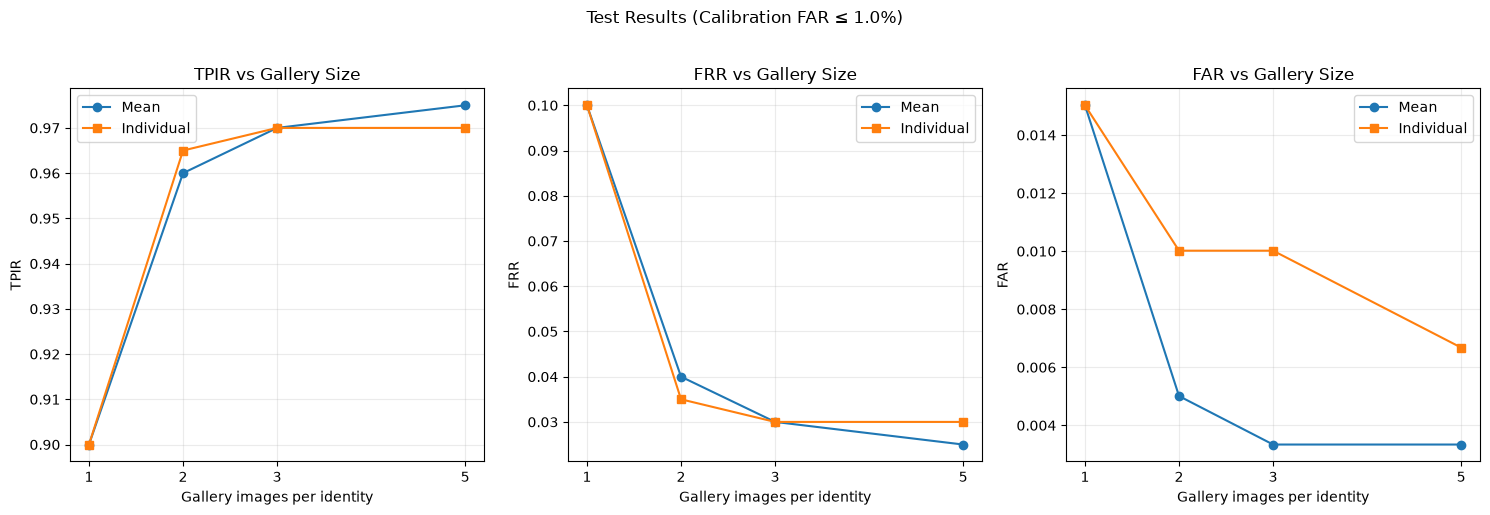

In [14]:
# =========================
# 14. EXPERIMENT: GALLERY SIZES (1, 2, 3, 5, 8)
# =========================
# Lặp lại quy trình CẢ CALIB LẪN TEST cho mỗi gallery size.

def evaluate_gallery_size_protocol(size, target_far=0.01):
    subset_paths = {}
    for identity in enrolled_names:
        paths = gallery_paths[identity][:size]
        if paths: subset_paths[identity] = paths

    # Xây dựng gallery VÀ thu thập thống kê về outlier filtering
    gallery_means_s, gallery_individuals_s, enrollment_stats = {}, {}, []
    for identity, paths in subset_paths.items():
        embs = [embedding_store[p] for p in paths if embedding_store[p] is not None]
        if not embs: continue
        mean_emb, _, valid_embs = build_identity_embedding(embs, outlier_threshold=OUTLIER_THRESHOLD)
        gallery_means_s[identity] = mean_emb.astype(np.float32)
        gallery_individuals_s[identity] = [np.asarray(e, np.float32) for e in valid_embs]
        enrollment_stats.append({
            "requested": len(paths),
            "effective": len(valid_embs),
            "outliers_removed": len(embs) - len(valid_embs),
        })

    gm, gi = gallery_means_s, gallery_individuals_s
    stats_df = pd.DataFrame(enrollment_stats)
    mean_eff = stats_df["effective"].mean() if not stats_df.empty else 0
    mean_out = stats_df["outliers_removed"].mean() if not stats_df.empty else 0

    c_df  = build_scoring_df(calib_query_paths,    gm, gi)
    t_df  = build_scoring_df(test_query_paths,     gm, gi)
    ci_df = build_scoring_df(calib_impostor_paths, gm, gi)
    ti_df = build_scoring_df(test_impostor_paths,  gm, gi)

    c_eval_m = evaluate_thresholds(c_df, ci_df, "score_mean",       "pred_mean")
    c_eval_i = evaluate_thresholds(c_df, ci_df, "score_individual", "pred_individual")

    thresh_m = find_lowest_threshold_meeting_far(c_eval_m, target_far)
    thresh_i = find_lowest_threshold_meeting_far(c_eval_i, target_far)

    common = {
        "Gallery (req)": size,
        "Eff. gallery (avg)": round(mean_eff, 2),
        "Outliers removed (avg)": round(mean_out, 2),
    }

    res_m = {}
    if thresh_m is not None:
        r = evaluate_thresholds(t_df, ti_df, "score_mean", "pred_mean", target_thresholds=[thresh_m]).iloc[0]
        res_m = {**common, "Method": "Mean", "Threshold": thresh_m,
                 "FAR (Test)": r["FAR"], "FRR (Test)": r["FRR"],
                 "MIS-ID (Test)": r["MIS_ID"], "TPIR (Test)": r["TPIR"]}

    res_i = {}
    if thresh_i is not None:
        r = evaluate_thresholds(t_df, ti_df, "score_individual", "pred_individual", target_thresholds=[thresh_i]).iloc[0]
        res_i = {**common, "Method": "Individual", "Threshold": thresh_i,
                 "FAR (Test)": r["FAR"], "FRR (Test)": r["FRR"],
                 "MIS-ID (Test)": r["MIS_ID"], "TPIR (Test)": r["TPIR"]}

    return [r for r in [res_m, res_i] if r]

if COMPARE_GALLERY_SIZES:
    final_results = []
    for size in GALLERY_SIZES_TO_COMPARE:
        print(f"Running for gallery size {size}...")
        final_results.extend(evaluate_gallery_size_protocol(size, target_far=TARGET_FAR))

    raw_df = pd.DataFrame(final_results)

    # Format % columns cho bảng hiển thị
    display_df = raw_df.copy()
    for col in ["FAR (Test)", "FRR (Test)", "MIS-ID (Test)", "TPIR (Test)"]:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")
    display(display_df)

    # --- Biểu đồ FAR / FRR / TPIR ---
    import matplotlib.pyplot as plt
    mean_df = raw_df[raw_df["Method"] == "Mean"]
    ind_df  = raw_df[raw_df["Method"] == "Individual"]

    sizes = list(GALLERY_SIZES_TO_COMPARE)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metrics = [("TPIR (Test)", "TPIR"), ("FRR (Test)", "FRR"), ("FAR (Test)", "FAR")]
    for ax, (col, label) in zip(axes, metrics):
        ax.plot(mean_df["Gallery (req)"], mean_df[col], marker="o", label="Mean")
        ax.plot(ind_df["Gallery (req)"],  ind_df[col],  marker="s", label="Individual")
        ax.set_title(f"{label} vs Gallery Size")
        ax.set_xlabel("Gallery images per identity")
        ax.set_ylabel(label)
        ax.set_xticks(sizes)
        ax.grid(True, alpha=0.25)
        ax.legend()
    plt.suptitle(f"Test Results (Calibration FAR ≤ {TARGET_FAR:.1%})", y=1.02)
    plt.tight_layout()
    plt.show()
